<a href="https://colab.research.google.com/github/changsin/polysemy_xlang_wsi/blob/main/notebooks/polysemy_robustness_checks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Robustness Checks

## 5.2 Robustness check

This section of the notebook performs a **robustness check** to ensure that the observed differences in polysemy between English and Chinese lemmas are not an artifact of comparing potentially dissimilar sets of words.

Here's what the robustness check entails:

1.  **Identifying Co-occurrence Pairs**: The first step is to identify "lemma co-occurrence pairs". These are pairs of English and Chinese lemmas that appear together in the same 'verse_id' (e.g., the same biblical verse). For instance, if the English lemma 'love' and the Chinese lemma '爱' (ài) both appear in verse John 3:16, they form a co-occurrence pair for that verse.

2.  **Counting Co-occurrences**: The code then counts how many times each unique (English lemma, Chinese lemma) pair co-occurs across all verses. This gives a measure of how strongly associated these cross-lingual lemma pairs are.

3.  **Filtering for Strong Overlaps**: To focus on robust comparisons, only pairs that co-occur at least 10 times are retained. These are considered "strong overlaps" and form the basis for the subsequent analysis.

4.  **Restricting WSI Results**: The next step restricts the Word Sense Induction (WSI) results for both English and Chinese to include *only* those lemmas that participated in these strong co-occurrence pairs. This ensures that the comparison is made on a set of lemmas that have clear cross-lingual counterparts.

5.  **Re-running Statistical Tests**: Finally, the Mann-Whitney U test and the frequency-stratified comparison (which were previously run on the full sets of lemmas) are re-executed, but this time only on the filtered sets of overlapping lemmas. This verifies if the significant differences in polysemy between English and Chinese persist even when controlling for cross-lingual co-occurrence.

In essence, the robustness check aims to strengthen the confidence in the findings by ensuring they hold under more stringent comparison conditions, specifically by focusing on lemmas that are directly comparable across languages due to their shared textual context.

## 5.2.0 Load data

Upload the following files under `bible_data`:
- enlgish_wsi_results.csv
- chinese_wsi_results.csv
- english_sense_labels.csv
- chinese_sense_labels.csv
- english_embeddings.npz
- chinese_embeddings.npz

In [39]:
import pandas as pd
from pathlib import Path
DATA_DIR = Path("/content") / "bible_data"
OUTPUT_DIR = Path("/content") / "output"
FIG_DIR    = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

# Load the WSI results for English and Chinese, if not already loaded
en = pd.read_csv(DATA_DIR / "english_wsi_results.csv")
zh = pd.read_csv(DATA_DIR / "chinese_wsi_results.csv")

# Load per-instance sense labels
en_labels = pd.read_csv(DATA_DIR / "english_sense_labels.csv")
zh_labels = pd.read_csv(DATA_DIR / "chinese_sense_labels.csv")

### 5.2.1 Build lemma co-occurence pairs

In [40]:
print("\n" + "="*60)
print("Step 8: Overlap-Only Robustness Check")
print("="*60)

# Load per-instance sense labels
en_labels = pd.read_csv(DATA_DIR / "english_sense_labels.csv")
zh_labels = pd.read_csv(DATA_DIR / "chinese_sense_labels.csv")

# Merge on verse_id to get co-occurring lemmas
merged = en_labels.merge(
    zh_labels,
    on="verse_id",
    suffixes=("_en", "_zh")
)

# Count lemma co-occurrence pairs
pair_counts = (
    merged.groupby(["lemma_en", "lemma_zh"])
    .size()
    .reset_index(name="co_occurrences")
)

# Keep only strong overlaps (at least 10 shared verses)
pair_counts = pair_counts[pair_counts["co_occurrences"] >= 10]

print(f"Total aligned lemma pairs: {len(pair_counts)}")


Step 8: Overlap-Only Robustness Check
Total aligned lemma pairs: 4689


### 5.2.2 Identify overlapping lemma sets

In [41]:
# Lemmas that participate in aligned pairs
en_overlap = set(pair_counts["lemma_en"])
zh_overlap = set(pair_counts["lemma_zh"])

print(f"English overlapping lemmas: {len(en_overlap)}")
print(f"Chinese overlapping lemmas: {len(zh_overlap)}")

English overlapping lemmas: 595
Chinese overlapping lemmas: 473


5.2.3 Restrict WSI results to overlap lemmas only

In [42]:
en_overlap_df = en[en["lemma"].isin(en_overlap)]
zh_overlap_df = zh[zh["lemma"].isin(zh_overlap)]

print(f"Filtered EN lemmas: {len(en_overlap_df)}")
print(f"Filtered ZH lemmas: {len(zh_overlap_df)}")

Filtered EN lemmas: 595
Filtered ZH lemmas: 473


### 5.2.4 Run Mann-Whitney on overlap only

In [43]:
from scipy.stats import mannwhitneyu

U, p = mannwhitneyu(
    en_overlap_df["k_hdbscan"],
    zh_overlap_df["k_hdbscan"],
    alternative="two-sided"
)

print("\n── Overlap-Only Statistical Comparison ──")
print(f"EN mean k: {en_overlap_df['k_hdbscan'].mean():.3f}")
print(f"ZH mean k: {zh_overlap_df['k_hdbscan'].mean():.3f}")
print(f"p-value: {p:.6f}")


── Overlap-Only Statistical Comparison ──
EN mean k: 1.926
ZH mean k: 1.237
p-value: 0.000000


In [44]:
print("\n" + "="*60)
print("Frequency-Matched Polysemy Comparison (Overlap Only)")
print("="*60)

# Define bins
bins = [30, 60, 100, 200, 500, 1000]
labels = ["30–59", "60–99", "100–199", "200–499", "500+"]

def assign_bin(n):
    for i in range(len(bins)-1):
        if bins[i] <= n < bins[i+1]:
            return labels[i]
    if n >= bins[-1]:
        return labels[-1]
    return None

# Assign bins to overlap dataframes directly
en_overlap_df = en_overlap_df.copy()
zh_overlap_df = zh_overlap_df.copy()

en_overlap_df["freq_bin"] = en_overlap_df["n_instances"].apply(assign_bin)
zh_overlap_df["freq_bin"] = zh_overlap_df["n_instances"].apply(assign_bin)

# Remove words outside bins
en_bin_overlap_df = en_overlap_df.dropna(subset=["freq_bin"])
zh_bin_overlap_df = zh_overlap_df.dropna(subset=["freq_bin"])

bin_results = []

for bin_label in labels:
    en_subset = en_bin_overlap_df[
        en_bin_overlap_df["freq_bin"] == bin_label
    ]["k_hdbscan"]

    zh_subset = zh_bin_overlap_df[
        zh_bin_overlap_df["freq_bin"] == bin_label
    ]["k_hdbscan"]

    if len(en_subset) < 5 or len(zh_subset) < 5:
        continue

    from scipy.stats import mannwhitneyu
    U, p = mannwhitneyu(en_subset, zh_subset, alternative="two-sided")

    bin_results.append({
        "freq_bin": bin_label,
        "en_mean_k": en_subset.mean(),
        "zh_mean_k": zh_subset.mean(),
        "n_en": len(en_subset),
        "n_zh": len(zh_subset),
        "p_value": p
    })

bin_df = pd.DataFrame(bin_results)

print("\n── Frequency-Stratified Results (Overlap Only) ──")
print(bin_df)

bin_df.to_csv(
    OUTPUT_DIR / "frequency_matched_comparison_overlap_df.csv",
    index=False
)


Frequency-Matched Polysemy Comparison (Overlap Only)

── Frequency-Stratified Results (Overlap Only) ──
  freq_bin  en_mean_k  zh_mean_k  n_en  n_zh       p_value
0    30–59   1.502370   1.100000   211   200  1.253895e-16
1    60–99   1.813793   1.264463   145   121  6.957939e-12
2  100–199   1.984848   1.348837   132    86  6.848508e-09
3  200–499   2.760000   1.460000    75    50  8.011587e-07
4     500+   3.031250   1.437500    32    16  2.476788e-05


## 5.3 Bootstrap Stability

In [45]:
RANDOM_STATE  = 42

# The threshold to do PCA reduction
LARGE_SAMPLE_SIZE = 200
# Max number of components to keep for PCA
COMPONENTS_UPPPER_LIMIT = 100

# HDBSCAN specific constants
# minimum number of datapoints to be considered as a cluster
MIN_CLUSTER_DATA_SIZE = 6
# minimum percentage of datapoints with respect to the total datapoints
MIN_CLUSTER_DATA_PROPORTION = 0.03
# If the second largest cluster is below this proportion, count as monosemous
SECOND_CLUSTER_THRESHOLD = 0.08

# ─── HDBSCAN ──────────────────────────────────────────────

import hdbscan
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize


def induce_senses_hdbscan(embeddings: np.ndarray):
    n_samples, n_features = embeddings.shape

    if n_samples < 20:
        return 1, np.zeros(n_samples, dtype=int)

    # L2 normalize
    embeddings = normalize(embeddings)

    # Optional PCA only if large sample size
    if n_samples > LARGE_SAMPLE_SIZE:
        n_components = min(COMPONENTS_UPPPER_LIMIT,
                           n_samples - 1,
                           n_features)
        embeddings = PCA(
            n_components=n_components,
            random_state=RANDOM_STATE
        ).fit_transform(embeddings)
        embeddings = normalize(embeddings)

    # too conservative
    # min_cluster_size = max(8, int(0.05 * n_samples))
    # More liberal parameters  3% instead of 5%
    min_cluster_size = max(MIN_CLUSTER_DATA_SIZE,
                           int(MIN_CLUSTER_DATA_PROPORTION * n_samples))


    clusterer = hdbscan.HDBSCAN(
        metric="euclidean",
        min_cluster_size=min_cluster_size,
        min_samples=max(5, min_cluster_size // 2),
        cluster_selection_method="eom"
    )

    labels = clusterer.fit_predict(embeddings)

    clusters = set(labels)
    clusters.discard(-1)

    k = len(clusters)

    if k <= 1:
        return 1, np.zeros(n_samples, dtype=int)

    sizes = sorted([sum(labels == c) for c in clusters], reverse=True)

    # Use the configurable variable
    if sizes[1] / n_samples < SECOND_CLUSTER_THRESHOLD:
        return 1, np.zeros(n_samples, dtype=int)

    return k, labels

### 5.3.1 Bootstrap function

In [46]:
import numpy as np
from collections import Counter

def bootstrap_k(embeddings, n_runs=20, sample_ratio=0.8):
    """
    Bootstrap stability for a single lemma.

    Returns:
        mode_k     : most frequent induced k across runs
        stability  : proportion of runs equal to mode_k
        all_ks     : list of k from each run
    """
    n = len(embeddings)

    if n < 20:
        return 1, 1.0, [1]

    ks = []

    for _ in range(n_runs):
        sample_size = int(sample_ratio * n)
        idx = np.random.choice(n, sample_size, replace=False)
        subset = embeddings[idx]

        k, _ = induce_senses_hdbscan(subset)
        ks.append(k)

    counter = Counter(ks)
    mode_k = counter.most_common(1)[0][0]
    stability = counter[mode_k] / n_runs

    return mode_k, stability, ks

### 5.3.2 Run Bootstrap for Entire Language

In [47]:
def run_bootstrap_for_language(lang: str, n_runs=20):
    print(f"\n[{lang.upper()}] Running bootstrap stability...")

    embeddings_file = DATA_DIR / f"{lang}_embeddings.npz"
    results_file = DATA_DIR / f"{lang}_wsi_results.csv"

    data = np.load(embeddings_file, allow_pickle=True)
    lemmas_array = data["lemmas"]
    embeddings = data["embeddings"]

    df = pd.read_csv(results_file)

    stability_records = []

    unique_lemmas = df["lemma"].values

    for i, lemma in enumerate(unique_lemmas):
        mask = (lemmas_array == lemma)
        lemma_embeds = embeddings[mask]

        mode_k, stability, ks = bootstrap_k(
            lemma_embeds,
            n_runs=n_runs,
            sample_ratio=0.8
        )

        stability_records.append({
            "lemma": lemma,
            "n_instances": len(lemma_embeds),
            "k_bootstrap_mode": mode_k,
            "stability": stability
        })

        if (i + 1) % 50 == 0 or (i + 1) == len(unique_lemmas):
            print(f"  {i+1}/{len(unique_lemmas)} lemmas", end="\r")

    stability_df = pd.DataFrame(stability_records)

    out_path = DATA_DIR / f"{lang}_bootstrap_stability.csv"
    stability_df.to_csv(out_path, index=False)

    print(f"\n[{lang.upper()}] Saved bootstrap results → {out_path.name}")

    return stability_df

### 5.3.3 Run for both languages

In [48]:
en_boot = run_bootstrap_for_language("english", n_runs=20)
zh_boot = run_bootstrap_for_language("chinese", n_runs=20)


[ENGLISH] Running bootstrap stability...
  636/636 lemmas
[ENGLISH] Saved bootstrap results → english_bootstrap_stability.csv

[CHINESE] Running bootstrap stability...
  496/496 lemmas
[CHINESE] Saved bootstrap results → chinese_bootstrap_stability.csv


### 5.3.4 Compare stability across languages

In [49]:
print("\n" + "="*60)
print("Bootstrap Stability Comparison")
print("="*60)

print(f"EN mean stability: {en_boot['stability'].mean():.3f}")
print(f"ZH mean stability: {zh_boot['stability'].mean():.3f}")

from scipy.stats import mannwhitneyu

U, p = mannwhitneyu(
    en_boot["stability"],
    zh_boot["stability"],
    alternative="two-sided"
)

print(f"Stability difference p-value: {p:.6f}")


Bootstrap Stability Comparison
EN mean stability: 0.872
ZH mean stability: 0.943
Stability difference p-value: 0.000000


### 5.3.5 Compare stability for polysemous lemmas only

In [50]:
en_poly = en_boot[en_boot["k_bootstrap_mode"] > 1]
zh_poly = zh_boot[zh_boot["k_bootstrap_mode"] > 1]

print("\nPolysemous-only stability:")
print(f"EN mean stability: {en_poly['stability'].mean():.3f}")
print(f"ZH mean stability: {zh_poly['stability'].mean():.3f}")

U_poly, p_poly = mannwhitneyu(
    en_poly["stability"],
    zh_poly["stability"],
    alternative="two-sided"
)

print(f"Polysemous stability p-value: {p_poly:.6f}")


Polysemous-only stability:
EN mean stability: 0.841
ZH mean stability: 0.799
Polysemous stability p-value: 0.123057


## 5.4 Regression Model

### 5.4.1 Merge and Prepare Data

In [51]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from pathlib import Path

# Ensure 'en' and 'zh' DataFrames are available.
DATA_DIR = Path("/content") / "bible_data"
en = pd.read_csv(DATA_DIR / "english_wsi_results.csv")
zh = pd.read_csv(DATA_DIR / "chinese_wsi_results.csv")

# Add language label
en["language"] = 1   # English
zh["language"] = 0   # Chinese

# Combine
df = pd.concat([en, zh], ignore_index=True)

# Log frequency
df["log_freq"] = np.log(df["n_instances"])

# Response variable
df["k"] = df["k_hdbscan"]

### 5.4.2 Poisson Regression

In [52]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np
import statsmodels.api as sm
from pathlib import Path

# Ensure 'en' and 'zh' DataFrames are available.
DATA_DIR = Path("/content") / "bible_data"
en = pd.read_csv(DATA_DIR / "english_wsi_results.csv")
zh = pd.read_csv(DATA_DIR / "chinese_wsi_results.csv")

# Add language label
en["language"] = 1   # English
zh["language"] = 0   # Chinese

# Combine
df = pd.concat([en, zh], ignore_index=True)

# Log frequency
df["log_freq"] = np.log(df["n_instances"])

# Response variable
df["k"] = df["k_hdbscan"]

poisson_model = smf.glm(
    formula="k ~ language + log_freq",
    data=df,
    family=sm.families.Poisson()
).fit()

print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      k   No. Observations:                 1132
Model:                            GLM   Df Residuals:                     1129
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1480.9
Date:                Thu, 19 Mar 2026   Deviance:                       343.25
Time:                        15:09:59   Pearson chi2:                     392.
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1208
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.7253      0.118     -6.170      0.0

### 5.4.3 Check for Overdispersion

In [53]:
mean_k = df["k"].mean()
var_k = df["k"].var()

print("Mean k:", mean_k)
print("Variance k:", var_k)

Mean k: 1.598939929328622
Variance k: 0.884101439359136


### 5.4.4 Negative Binomial Regression

In [54]:
nb_model = smf.glm(
    formula="k ~ language + log_freq",
    data=df,
    family=sm.families.NegativeBinomial()
).fit()

print(nb_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      k   No. Observations:                 1132
Model:                            GLM   Df Residuals:                     1129
Model Family:        NegativeBinomial   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1933.3
Date:                Thu, 19 Mar 2026   Deviance:                       116.03
Time:                        15:09:59   Pearson chi2:                     139.
No. Iterations:                     5   Pseudo R-squ. (CS):            0.04674
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.7306      0.200     -3.650      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


### 5.4.5 Interpret Language Coefficient

In [55]:
beta_lang = nb_model.params["language"]
p_lang = nb_model.pvalues["language"]

print("Language coefficient:", beta_lang)
print("p-value:", p_lang)

# Incidence Rate Ratio
irr = np.exp(beta_lang)
print("Incidence Rate Ratio (English vs Chinese):", irr)

Language coefficient: 0.38596900163734227
p-value: 8.161273421614853e-07
Incidence Rate Ratio (English vs Chinese): 1.4710390703053913


### 5.4.6 Visualization

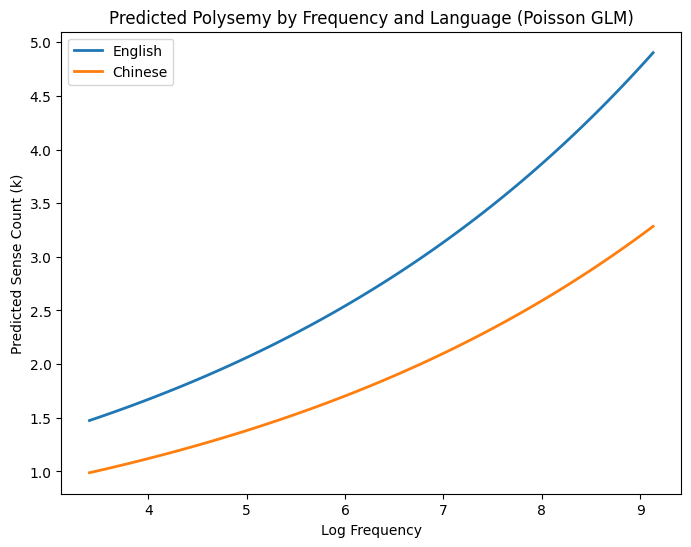

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# Create frequency range
freq_range = np.linspace(df["log_freq"].min(), df["log_freq"].max(), 100)

# Create prediction dataframe
pred_df_en = pd.DataFrame({
    "language": 1,
    "log_freq": freq_range
})

pred_df_zh = pd.DataFrame({
    "language": 0,
    "log_freq": freq_range
})

# Predict expected k
pred_en = poisson_model.predict(pred_df_en)
pred_zh = poisson_model.predict(pred_df_zh)

# Plot
plt.figure(figsize=(8,6))
plt.plot(freq_range, pred_en, label="English", linewidth=2)
plt.plot(freq_range, pred_zh, label="Chinese", linewidth=2)
plt.xlabel("Log Frequency")
plt.ylabel("Predicted Sense Count (k)")
plt.title("Predicted Polysemy by Frequency and Language (Poisson GLM)")
plt.legend()
plt.show()